##### --- 1. KÜTÜPHANELERİN İÇE AKTARILMASI ---

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#### --- 2. VERİ YÜKLEME VE İNCELEME ---

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [4]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [5]:
df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

#### --- 2. KATEGORİK DEĞİŞKEN DÖNÜŞÜMLERİ (FEATURE ENGINEERING) ---

İkili (Binary) kategorik değişkenleri 0 ve 1'e çeviriyoruz.

In [6]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [7]:
df['sex'] = df['sex'].map({"female" : 0 , "male" : 1})
df['smoker'] = df['smoker'].map({"no" : 0 , "yes" : 1})

In [8]:
# DİKKAT: Bölge (region) değişkeni 4 farklı değere sahip. 
# get_dummies ile One-Hot Encoding yaparken 'drop_first=True' kullanıyoruz ki Dummy Variable Trap'e düşmeyelim.
# 4 bölge varsa, 3 sütun bizim için yeterlidir.

df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

In [9]:
df.head()

,age,sex,bmi,children,smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,0,27.9,0,1,16884.92,0,0,1
1,18,1,33.8,1,0,1725.55,0,1,0
2,28,1,33.0,3,0,4449.46,0,1,0
3,33,1,22.7,0,0,21984.47,1,0,0
4,32,1,28.9,0,0,3866.86,1,0,0


#### --- 4. KEŞİFSEL VERİ ANALİZİ (EDA) ---

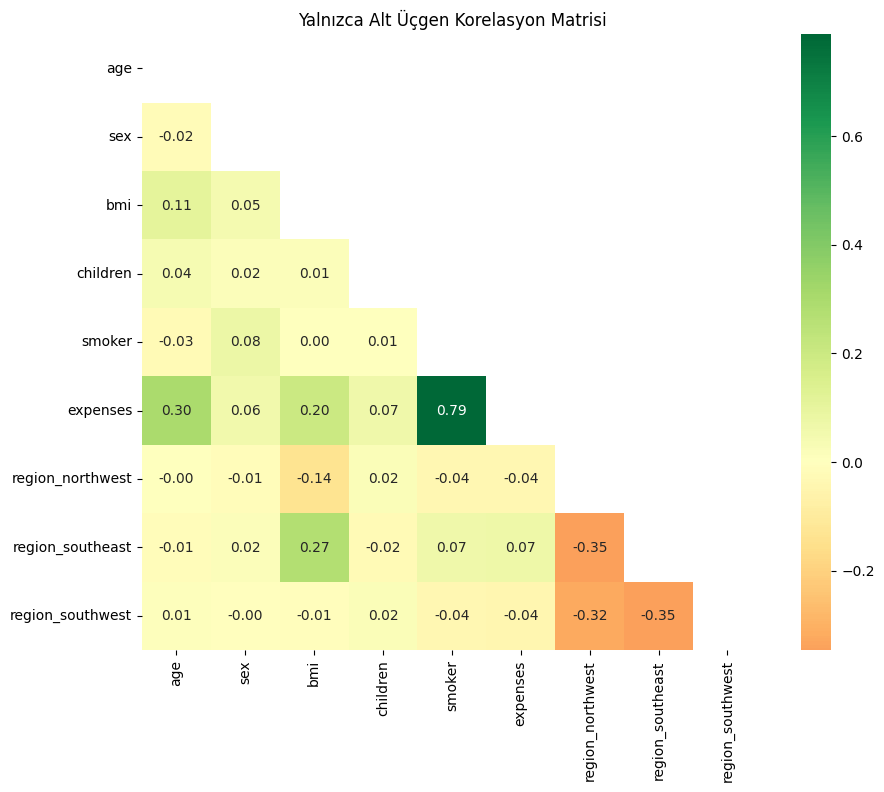

In [10]:
# 1. Korelasyon matrisini hesapla
corr = df.corr()

# 2. Üst üçgeni kapatacak bir maske oluştur
# np.triu (triangle upper) üst üçgeni seçer, biz bunu maske olarak kullanacağız
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Heatmap'i çizdir
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn', fmt=".2f", center=0)

plt.title('Yalnızca Alt Üçgen Korelasyon Matrisi')
plt.show()

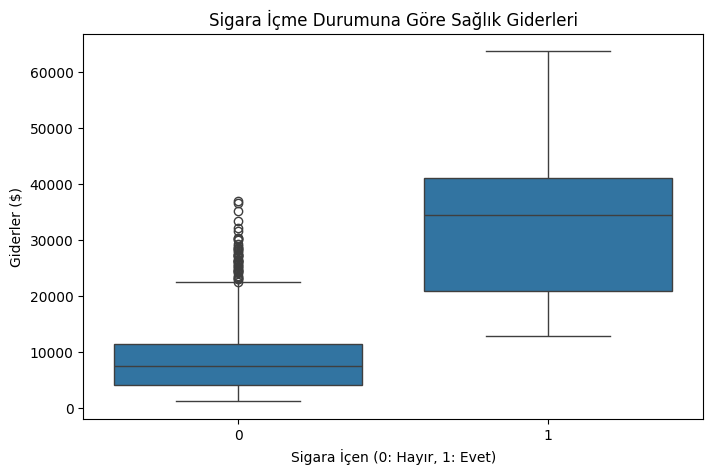

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="expenses")
plt.title("Sigara İçme Durumuna Göre Sağlık Giderleri")
plt.xlabel("Sigara İçen (0: Hayır, 1: Evet)")
plt.ylabel("Giderler ($)")
plt.show()

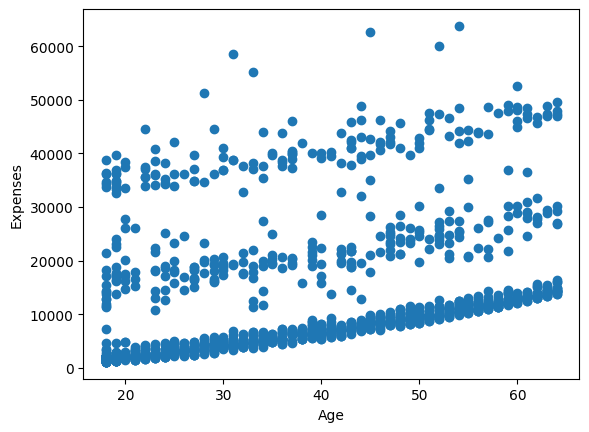

In [12]:
plt.scatter(data = df , x = "age" , y = "expenses")

plt.xlabel('Age')
plt.ylabel('Expenses')
plt.show()

#### --- 5. VERİ SETİNİ BÖLME (SPLIT) ---

In [13]:
X = df.drop("expenses" , axis = 1)
y = df['expenses']

In [14]:
df_columns = ["age","sex","bmi","children","smoker","region_northeast","region_northwest","region_southwest"]

In [15]:
df.head()

,age,sex,bmi,children,smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,0,27.9,0,1,16884.92,0,0,1
1,18,1,33.8,1,0,1725.55,0,1,0
2,28,1,33.0,3,0,4449.46,0,1,0
3,33,1,22.7,0,0,21984.47,1,0,0
4,32,1,28.9,0,0,3866.86,1,0,0


In [16]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size= 0.2 , random_state = 42)

#### --- 6. ÖLÇEKLENDİRME (SCALING) ---

In [17]:
scaler = StandardScaler()

In [18]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### --- 7. MODELLEME VE TAHMİN ---

In [19]:
model = LinearRegression()

In [20]:
model.fit(X_train_scaled , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = model.predict(X_test_scaled)

            Özellik  Katsayı (Ağırlık)
4            smoker        9558.151403
0               age        3614.697633
2               bmi        2037.268555
3          children         517.330947
1               sex          -9.257136
5  region_northwest        -157.985768
6  region_southeast        -290.531103
7  region_southwest        -348.865173


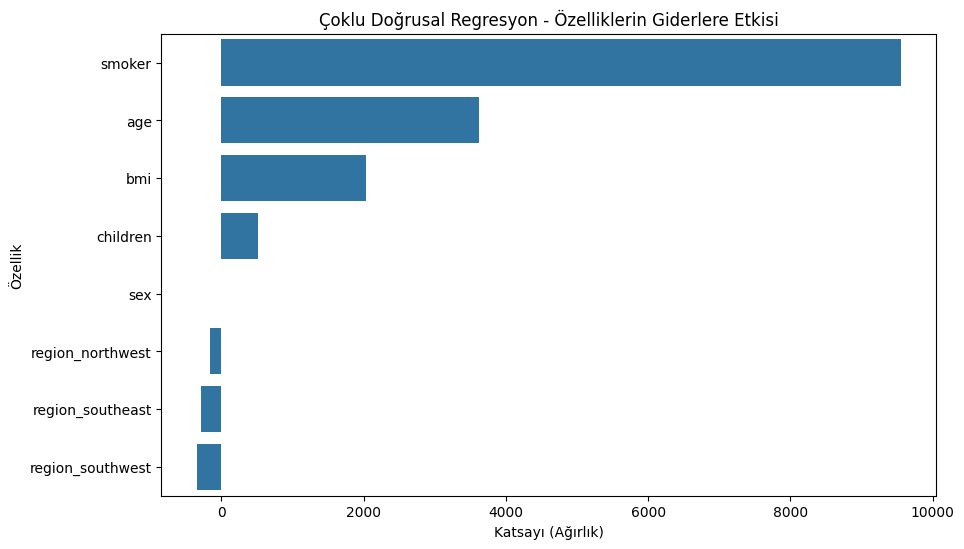

In [22]:
# Sütun isimlerini X_train üzerinden dinamik olarak alalım
feature_names = X.columns

# Katsayıları bir DataFrame'e dönüştürelim
coefficients = pd.DataFrame({
    'Özellik': feature_names,
    'Katsayı (Ağırlık)': model.coef_
})

# Katsayıları büyüklüğüne göre sıralayalım
coefficients = coefficients.sort_values(by='Katsayı (Ağırlık)', ascending=False)

print(coefficients)

# Görselleştirelim
plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, x='Katsayı (Ağırlık)', y='Özellik')
plt.title("Çoklu Doğrusal Regresyon - Özelliklerin Giderlere Etkisi")
plt.show()

#### --- 8. DEĞERLENDİRME METRİKLERİ ---

In [23]:
print("MAE Score : ", mean_absolute_error(y_test, y_pred))
print("MSE Score : ", mean_squared_error(y_test, y_pred))
print("RMSE Score : ", np.sqrt(mean_squared_error(y_test, y_pred))) # Gerçek dünya birimi (Dolar) için RMSE ekledik
print("R2 Score : ", r2_score(y_test, y_pred))

MAE Score :  4181.56152400079
MSE Score :  33600065.355077825
RMSE Score :  5796.556335884076
R2 Score :  0.7835726930039906


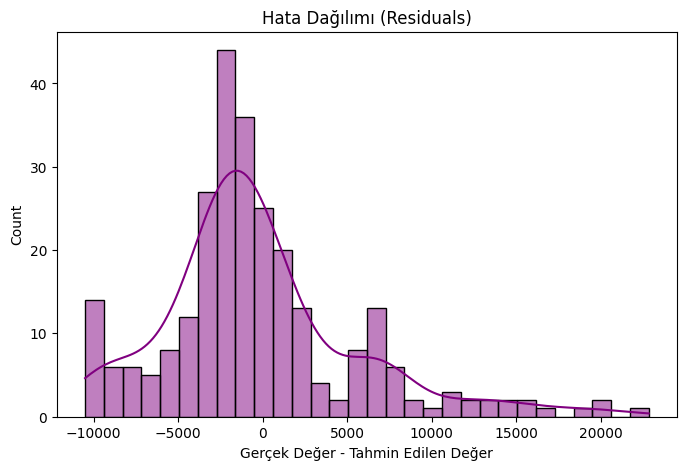

In [24]:
hata_paylari = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(hata_paylari, kde=True, bins=30, color='purple')
plt.title("Hata Dağılımı (Residuals)")
plt.xlabel("Gerçek Değer - Tahmin Edilen Değer")
plt.show()